# Sample Comparison — Frequency Spectra & Mel Spectrograms

Compare **any number** of audio clips side by side, first via the Fourier transform
(frequency spectrum) and then via mel spectrograms.

Edit the `AUDIO_FILES` list below to choose what to compare. The default lines up the
original violin recordings against the **sms-tools** degraded versions produced by
`degrade_violin.py` — the sinusoidal model (`sineModel`, partials only) and the
sinusoidal-plus-stochastic model (`spsModel`, partials + a stochastic residual).

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import parselmouth
from utils import load_audio

## Choose & Load Audio

List the clips to compare as `(label, path)` pairs in `AUDIO_FILES`. Paths are relative to
this notebook; the `.mp3` files live in the project root, one level up. Add or remove entries
freely — every plot below scales to however many files are listed.

In [106]:
# (label, path) — edit this list to compare any set of clips.
AUDIO_FILES = [
    # Single note / double stop, original vs sms-tools degraded.
    # ("D — original",   "../D_violin.mp3"),
    # ("D — spsModel",   "../D_violin_sps.mp3"),
    # ("D — sawtooth",   "../D_sawtooth.mp3"),

    # ("DA — original",  "../DA_violin.mp3"),
    # ("DA — sineModel", "../DA_violin_sine.mp3"),
    # ("DA — spsModel",  "../DA_violin_sps.mp3"),
    # Recorded violin samples (test_recordings/).
    
    # ("Open chords",        "../test_recordings/violin open chords.m4a"),
    # ("G string vs open D", "../test_recordings/violin G string vs open D.m4a"),

    # ("Scale (sawtooth)",      "../scale_sawtooth.mp3"),
    # ("Scale (legato)",       "../test_recordings/violin legato scale.m4a"),
    # ("Scale (slur)",       "../test_recordings/violin scale slur.m4a"),
    # ("Scale (spicc)",      "../test_recordings/violin scale spicc.m4a"),
    # ("Bach (no vib)",      "../test_recordings/bach no vib.m4a"),
    # ("Bach (vib)",         "../test_recordings/bach vib.m4a"),
    # ("Tchaikovsky",        "../test_recordings/tchaikovsky.m4a"),
    # ("Vibrato note",        "../test_recordings/vibrato note.m4a"),
]

AUDIO_FILES = [
    ("Prior",   "../Data/prior/Kayser_Op20-01_AlexandrosIakovou_O105paQOHCE-0004-0064.wav"),
    ("GT",   "../Data/gt/Kayser_Op20-01_AlexandrosIakovou_O105paQOHCE-0004-0064.wav"),
]

# Load each clip once into a list of (label, samples, sample_rate).
samples = []
for label, path in AUDIO_FILES:
    y, sr = load_audio(path)
    samples.append((label, y, sr))
    print(f"{label:>20}:  sample rate {sr} Hz,  "
          f"duration {len(y) / sr:.2f} s,  {len(y)} samples")

               Prior:  sample rate 44100 Hz,  duration 59.92 s,  2642673 samples
                  GT:  sample rate 44100 Hz,  duration 59.92 s,  2642673 samples


## Compute the Fourier Transform

We use NumPy's real FFT (`np.fft.rfft`), which handles arbitrary-length signals and is fast
enough to run across many clips. We keep the positive frequencies and convert to magnitude.

In [107]:
def spectrum(y, sr):
    """Return (freqs, magnitudes) via NumPy's real FFT."""
    X = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    magnitudes = np.abs(X) * 2 / len(y)
    return freqs, magnitudes

# Compute one spectrum per loaded clip.
spectra = [(label, *spectrum(y, sr)) for label, y, sr in samples]

## Frequency Spectrum

One row per clip, sharing a common frequency axis. Comparing a row against its `original`
counterpart shows what each sms-tools model keeps or discards: `sineModel` reduces to a clean
set of partials, while `spsModel` fills the gaps back in with a stochastic residual.

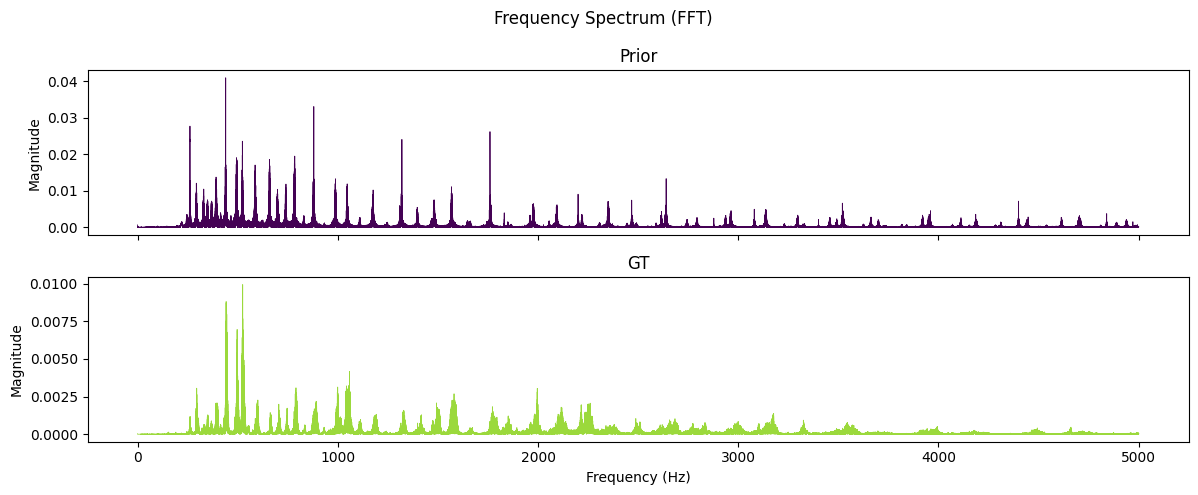

In [108]:
max_freq = 5000  # cap for readability

n = len(spectra)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
axes = np.atleast_1d(axes)
colors = plt.cm.viridis(np.linspace(0, 0.85, n))

for ax, (label, freqs, mags), color in zip(axes, spectra, colors):
    mask = freqs <= max_freq
    ax.plot(freqs[mask], mags[mask], linewidth=0.6, color=color)
    ax.set_title(label)
    ax.set_ylabel("Magnitude")

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle("Frequency Spectrum (FFT)")
plt.tight_layout()
plt.show()

## Mel Spectrograms (with F0 overlay)

A mel spectrogram shows how the frequency content evolves over time, with the frequency axis
warped to the perceptual mel scale and the magnitude shown in decibels. We first extract the
fundamental frequency (F0) with **parselmouth** (the Praat engine) so it can be overlaid on
each spectrogram and plotted on its own below.

`Sound.to_pitch()` returns an F0 estimate per frame; unvoiced frames come back as 0, which we
mask to `NaN` so the contour shows gaps. The floor/ceiling are set to the violin's range
(open G ≈ 196 Hz up through high positions).

In [109]:
def mel_db(y, sr, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    return librosa.power_to_db(S, ref=np.max)

F0_FLOOR = 180.0   # Hz, just below open-G (196 Hz)
F0_CEIL = 4000.0   # Hz, covers high positions

def f0_contour(y, sr):
    """Return (times, f0) where unvoiced frames are NaN so plots show gaps."""
    snd = parselmouth.Sound(y.astype(np.float64), sampling_frequency=sr)
    pitch = snd.to_pitch(pitch_floor=F0_FLOOR, pitch_ceiling=F0_CEIL)
    f0 = pitch.selected_array["frequency"]
    f0 = np.where(f0 > 0, f0, np.nan)
    return pitch.xs(), f0

# Compute one mel spectrogram and one F0 contour per loaded clip.
mels = [(label, mel_db(y, sr), sr) for label, y, sr in samples]
f0s = [(label, *f0_contour(y, sr)) for label, y, sr in samples]

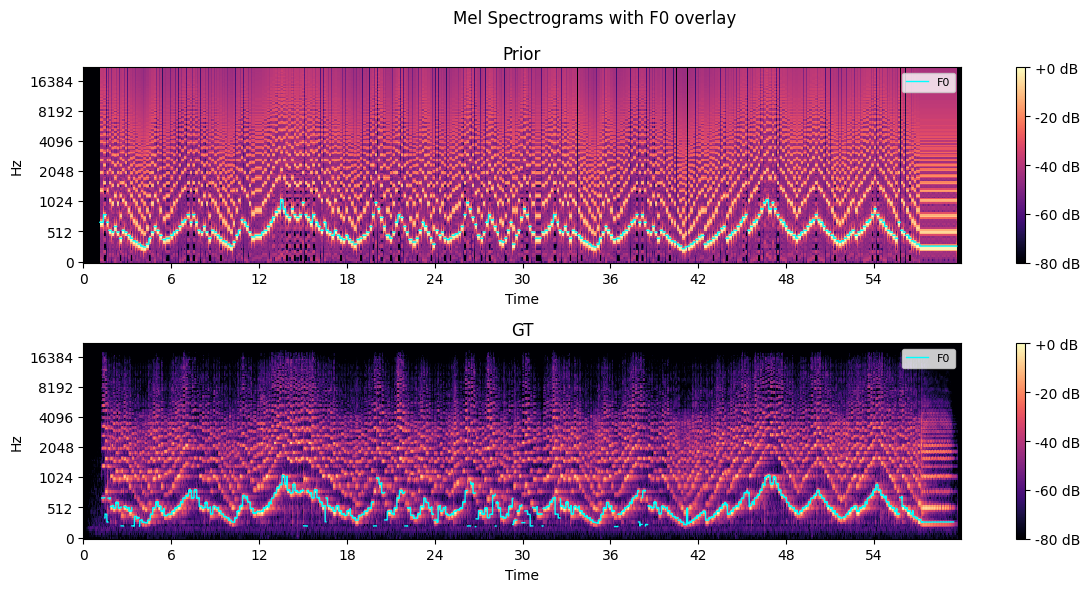

In [110]:
n = len(mels)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n))
axes = np.atleast_1d(axes)

# Shared time scale: longest clip's duration, so every row lines up in time.
max_dur = max(len(y) / sr for _, y, sr in samples)

for ax, (label, S, sr), (_, t, f0) in zip(axes, mels, f0s):
    img = librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="mel", ax=ax)
    # The mel axis is in Hz, so the F0 (Hz) contour overlays directly.
    ax.plot(t, f0, color="cyan", linewidth=1.0, label="F0")
    ax.set_xlim(0, max_dur)
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

fig.suptitle("Mel Spectrograms with F0 overlay")
plt.tight_layout()
plt.show()

### Difference Between the First Two Mel Spectrograms

Subtract the second clip's mel spectrogram from the first (both in dB) to highlight where they
diverge. A **diverging colormap** centres at zero: red means the first clip has more energy in
that time–frequency bin, blue means the second does, and white means they match. Frame counts
are trimmed to the shorter clip so the two grids line up.</cell id="diffmd0">

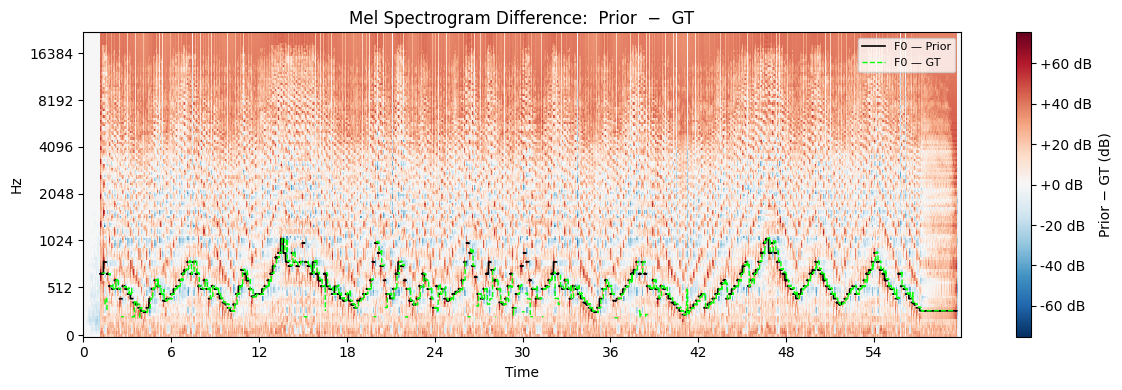

In [111]:
if len(mels) < 2:
    raise ValueError("Need at least two clips in AUDIO_FILES to compare.")

(label_a, S_a, sr_a), (label_b, S_b, sr_b) = mels[0], mels[1]

# Line up the two grids by trimming to the shorter clip's frame count.
n_frames = min(S_a.shape[1], S_b.shape[1])
diff = S_a[:, :n_frames] - S_b[:, :n_frames]

# Symmetric color limits so 0 dB sits at the centre of the diverging map.
vlim = np.abs(diff).max()

fig, ax = plt.subplots(figsize=(12, 4))
img = librosa.display.specshow(
    diff, sr=sr_a, x_axis="time", y_axis="mel",
    cmap="RdBu_r", vmin=-vlim, vmax=vlim, ax=ax,
)

# Overlay both clips' F0 contours (mel axis is in Hz, so they map directly).
(_, t_a, f0_a), (_, t_b, f0_b) = f0s[0], f0s[1]
ax.plot(t_a, f0_a, color="black", linewidth=1.2, label=f"F0 — {label_a}")
ax.plot(t_b, f0_b, color="lime", linewidth=1.0, linestyle="--", label=f"F0 — {label_b}")
ax.legend(loc="upper right", fontsize=8)

ax.set_title(f"Mel Spectrogram Difference:  {label_a}  −  {label_b}")
fig.colorbar(img, ax=ax, format="%+2.0f dB", label=f"{label_a} − {label_b} (dB)")
plt.tight_layout()
plt.show()

## Fundamental Frequency (F0)

The same F0 contours (extracted above), now on their own. The y-axis is **logarithmic and
shared across every clip**, so pitch height is directly comparable row-to-row and equal musical
intervals take up equal vertical space.

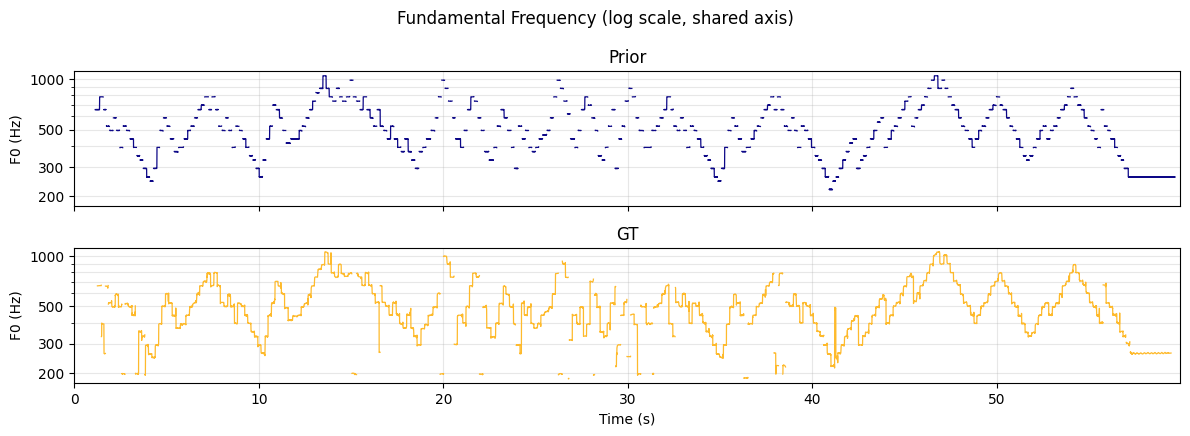

In [112]:
import matplotlib.ticker as mticker

# Shared, logarithmic F0 axis: global min/max across all voiced frames.
all_f0 = np.concatenate([f0 for _, _, f0 in f0s])
valid = all_f0[np.isfinite(all_f0)]
ymin, ymax = valid.min() * 0.95, valid.max() * 1.05

n = len(f0s)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.2 * n), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
colors = plt.cm.plasma(np.linspace(0, 0.85, n))

max_dur = max(len(y) / sr for _, y, sr in samples)

for ax, (label, t, f0), color in zip(axes, f0s, colors):
    ax.plot(t, f0, linewidth=0.9, color=color)
    ax.set_xlim(0, max_dur)
    ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1, 2, 3, 5)))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_title(label)
    ax.set_ylabel("F0 (Hz)")
    ax.grid(True, which="both", alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Fundamental Frequency (log scale, shared axis)")
plt.tight_layout()
plt.show()